# Four models: PCA + distances, PCA + dihedrals, tICA + distances, tICA + dihedrals

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import matplotlib.cm as cm
from deeptime.decomposition import TICA

data_folder = "./data/"

In [2]:
# set 1: distances
distances = np.loadtxt(data_folder + "hp35.mindists2", delimiter = " ", dtype = float)
print("Data shape", distances.shape) # [nm] nanometers
print("Data size (MB)", distances.nbytes / (10**6))

# set 2: dihedrals
#dihedrals = np.loadtxt(data_folder + "hp35.dihs.shifted", delimiter = " ", dtype = float)
#print(dihedrals.shape) # [radians] 

Data shape (1526041, 42)
Data size (MB) 512.749776


## PCA vs tICA

In [21]:
def plot_free_energy_projection(dimred_traj, component_x, component_y, ax = None, axlabel = "PC"):

    if ax == None:
        fig, ax__ = plt.subplots(1, 1, figsize=(5, 4))
    else:
        ax__ = ax

    # Scatter plot
    ax__.scatter(
        dimred_traj[:, component_x],
        dimred_traj[:, component_y],
        s=0.01,
        alpha=0.3
    )

    ax__.set_xlabel(f"{axlabel}{component_x}")
    ax__.set_ylabel(f"{axlabel}{component_y}")


    # 2D histogram (Free energy)
    H, xedges, yedges = np.histogram2d(
        dimred_traj[:, component_x],
        dimred_traj[:, component_y],
        bins=100,
        density=True
    )
    mask = H > 0
    F = np.full_like(H, np.nan)
    F[mask] = -np.log(H[mask])
    F -= np.nanmin(F)

    im = ax__.imshow(
        F.T,
        origin="lower",
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        aspect="auto"
    )

    plt.colorbar(im, ax=ax__, label=r"$F/k_B T$")
    ax__.set_xlabel(f"{axlabel}{component_x}")
    ax__.set_ylabel(f"{axlabel}{component_y}")
    

    return ax__

In [ ]:
X = distances

pca = PCA()
pca.fit(X)
pca_traj = pca.fit_transform(X)

In [33]:
tica = TICA(lagtime=1000, dim=4)
tica.fit(X)
tica_traj = tica.transform(X)

<Axes: xlabel='tIC1', ylabel='tIC2'>

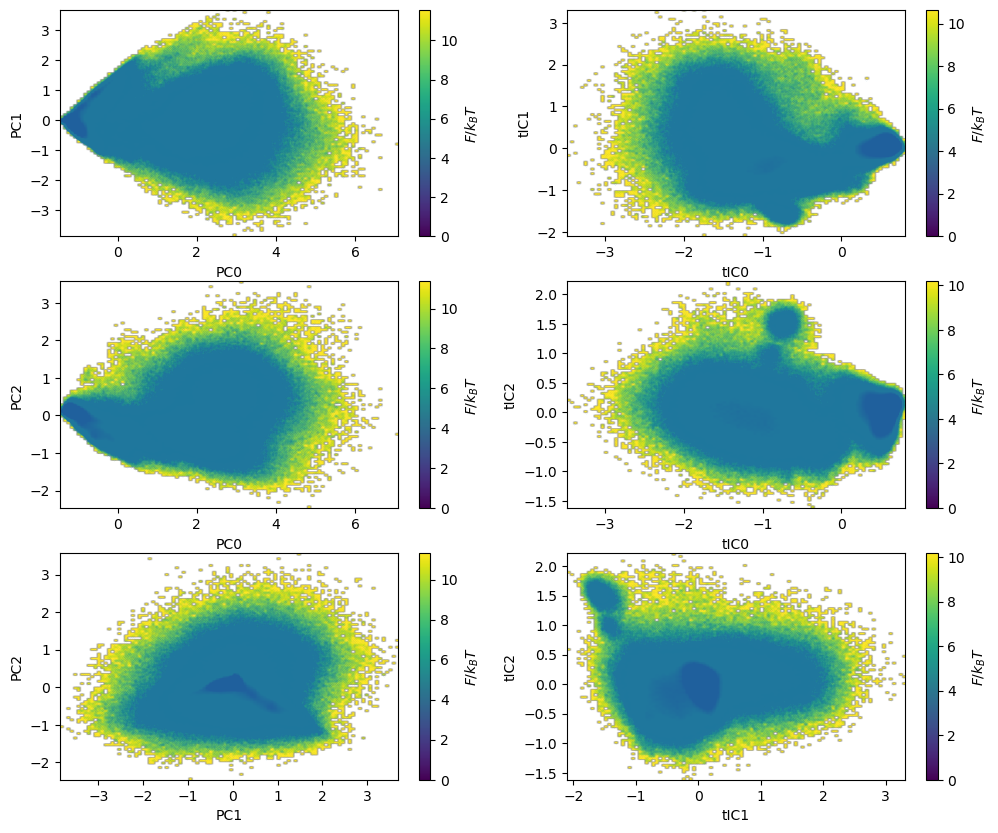

In [35]:
fig, axs = plt.subplots(3, 2, figsize=(12, 10))

plot_free_energy_projection(pca_traj, 0, 1, ax = axs[0, 0], axlabel = "PC")
plot_free_energy_projection(tica_traj, 0, 1, ax = axs[0, 1], axlabel = "tIC")


plot_free_energy_projection(pca_traj, 0, 2, ax = axs[1, 0], axlabel = "PC")
plot_free_energy_projection(tica_traj, 0, 2, ax = axs[1, 1], axlabel = "tIC")


plot_free_energy_projection(pca_traj, 1, 2, ax = axs[2, 0], axlabel = "PC")
plot_free_energy_projection(tica_traj, 1, 2, ax = axs[2, 1], axlabel = "tIC")

tICA eigenvalues